In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_patient_files, get_column_groups, summarize_missing

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

print("All imports successful!")

All imports successful!


In [2]:
#2— LOAD THE DATA - Load Set A only first (faster for exploration):

In [3]:
df = load_patient_files("../data/raw/setA", max_patients=5000)


Loading 5000 patient files...
  2000/5000 patients loaded...
  4000/5000 patients loaded...
Combining into single DataFrame...

=== Dataset Loaded ===
Total rows (patient-hours) : 194,835
Unique patients            : 5,000
Columns                    : 42
Sepsis cases (hours)       : 4,267
Sepsis rate                : 2.19%


In [4]:
#3 — Look at the raw data:

In [5]:
df.head(10)

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,NaN,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001
5,110.0,91.0,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,6,0,p000001
6,108.0,92.0,36.11,123.0,77.00,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,7,0,p000001
7,106.0,90.5,NaN,93.0,76.33,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,8,0,p000001
8,104.0,95.0,NaN,133.0,88.33,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,9,0,p000001
9,102.0,91.0,NaN,134.0,87.33,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,10,0,p000001


In [6]:
#4 — Basic shape:

In [7]:
print(f"Shape: {df.shape}")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.dtypes

Shape: (194835, 42)
Rows: 194,835
Columns: 42


HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2               float64
SaO2                float64
AST                 float64
BUN                 float64
Alkalinephos        float64
Calcium             float64
Chloride            float64
Creatinine          float64
Bilirubin_direct    float64
Glucose             float64
Lactate             float64
Magnesium           float64
Phosphate           float64
Potassium           float64
Bilirubin_total     float64
TroponinI           float64
Hct                 float64
Hgb                 float64
PTT                 float64
WBC                 float64
Fibrinogen          float64
Platelets           float64
Age                 float64
Gender              

In [8]:
#5 — Missing data report:

In [9]:
missing = summarize_missing(df)
print("Top 15 columns with most missing data:")
print(missing.head(15).to_string(index=False))

Top 15 columns with most missing data:
          column  missing_rate  missing_pct
           EtCO2      1.000000        100.0
       TroponinI      0.998773         99.9
Bilirubin_direct      0.998322         99.8
      Fibrinogen      0.992178         99.2
 Bilirubin_total      0.987949         98.8
    Alkalinephos      0.985459         98.5
             AST      0.985064         98.5
         Lactate      0.964652         96.5
             PTT      0.951775         95.2
         Calcium      0.950933         95.1
       Phosphate      0.949876         95.0
            SaO2      0.949229         94.9
       Platelets      0.934883         93.5
      Creatinine      0.934226         93.4
             WBC      0.924659         92.5


In [10]:
#6. Patient Age Distribution

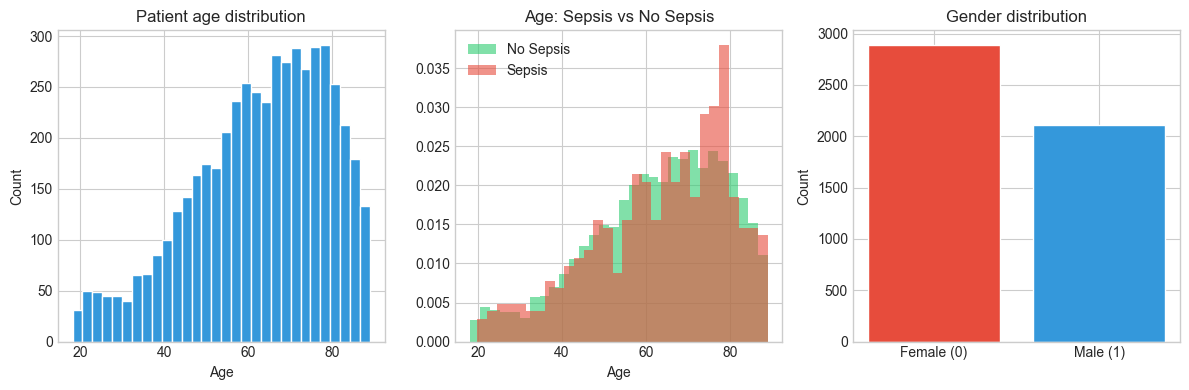

Average age: 62.7 years
Sepsis patients avg age: 63.7 years
Non-sepsis patients avg age: 62.6 years


In [11]:
# Get one row per patient (demographics don't change hour to hour)
patients = df.groupby('patient_id').first().reset_index()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
patients['Age'].hist(bins=30, color='#3498db', edgecolor='white')
plt.title('Patient age distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sepsis_patients = df[df['SepsisLabel']==1]['patient_id'].unique()
sepsis_ages = patients[patients['patient_id'].isin(sepsis_patients)]['Age']
no_sepsis_ages = patients[~patients['patient_id'].isin(sepsis_patients)]['Age']
plt.hist(no_sepsis_ages, bins=30, alpha=0.6, color='#2ecc71', 
         label='No Sepsis', density=True)
plt.hist(sepsis_ages, bins=30, alpha=0.6, color='#e74c3c', 
         label='Sepsis', density=True)
plt.title('Age: Sepsis vs No Sepsis')
plt.xlabel('Age')
plt.legend()

plt.subplot(1, 3, 3)
gender_counts = patients['Gender'].value_counts()
plt.bar(['Female (0)', 'Male (1)'], gender_counts.values, 
        color=['#e74c3c','#3498db'], edgecolor='white')
plt.title('Gender distribution')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('age_gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Average age: {patients['Age'].mean():.1f} years")
print(f"Sepsis patients avg age: {sepsis_ages.mean():.1f} years")
print(f"Non-sepsis patients avg age: {no_sepsis_ages.mean():.1f} years")

In [12]:
#7 — Vital signs: sepsis vs no sepsis:

HR       | No Sepsis avg: 85.0 | Sepsis avg: 90.5 | Difference: +5.5
O2Sat    | No Sepsis avg: 97.3 | Sepsis avg: 96.9 | Difference: -0.4
Temp     | No Sepsis avg: 37.0 | Sepsis avg: 37.3 | Difference: +0.2
SBP      | No Sepsis avg: 120.4 | Sepsis avg: 120.1 | Difference: -0.3
MAP      | No Sepsis avg: 78.4 | Sepsis avg: 77.5 | Difference: -1.0
DBP      | No Sepsis avg: 59.7 | Sepsis avg: 59.3 | Difference: -0.4
Resp     | No Sepsis avg: 18.7 | Sepsis avg: 20.6 | Difference: +1.9


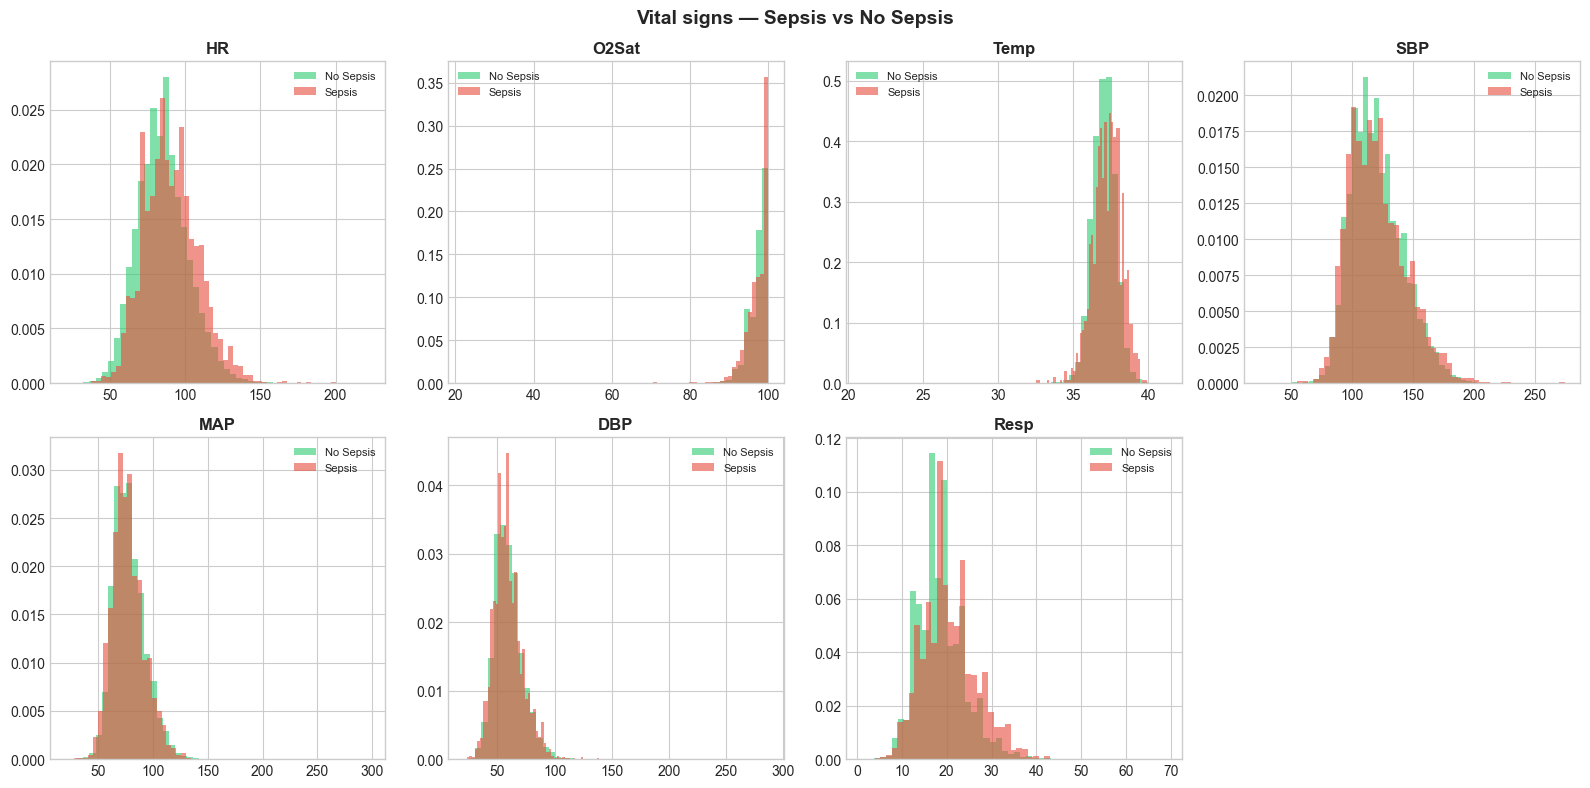

In [13]:
cols = get_column_groups()
vitals = cols['vitals']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(vitals):
    sepsis_vals = df[df.SepsisLabel==1][col].dropna()
    normal_vals = df[df.SepsisLabel==0][col].dropna()
    
    axes[i].hist(normal_vals, bins=50, alpha=0.6,
                 color='#2ecc71', label='No Sepsis', density=True)
    axes[i].hist(sepsis_vals, bins=50, alpha=0.6,
                 color='#e74c3c', label='Sepsis', density=True)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)
    
    # Print the difference
    diff = sepsis_vals.mean() - normal_vals.mean()
    print(f"{col:8} | No Sepsis avg: {normal_vals.mean():.1f} "
          f"| Sepsis avg: {sepsis_vals.mean():.1f} "
          f"| Difference: {diff:+.1f}")

axes[-1].set_visible(False)
plt.suptitle('Vital signs — Sepsis vs No Sepsis', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vitals_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# 8 — ICU stay length:

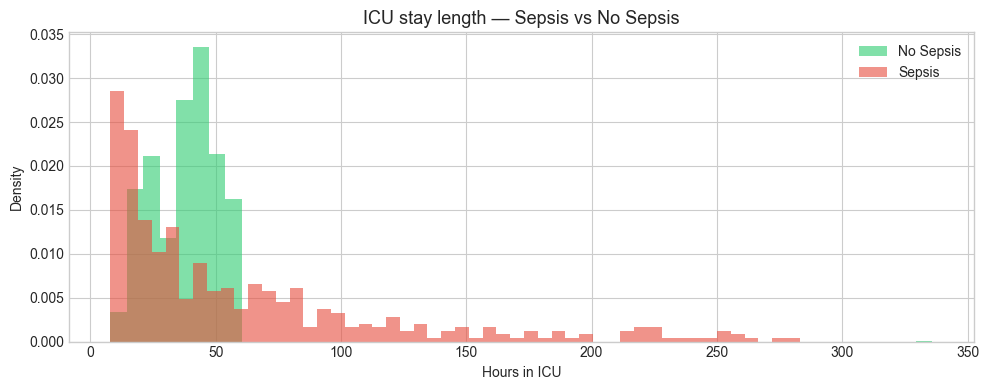

Avg ICU stay — No Sepsis : 37.8 hours
Avg ICU stay — Sepsis    : 59.9 hours
Sepsis patients stay 1.6x longer


In [15]:
stay_length = df.groupby('patient_id')['ICULOS'].max().reset_index()
stay_length.columns = ['patient_id', 'icu_hours']

sepsis_stay = stay_length[
    stay_length['patient_id'].isin(sepsis_patients)]['icu_hours']
normal_stay = stay_length[
    ~stay_length['patient_id'].isin(sepsis_patients)]['icu_hours']

plt.figure(figsize=(10, 4))
plt.hist(normal_stay, bins=50, alpha=0.6, color='#2ecc71',
         label='No Sepsis', density=True)
plt.hist(sepsis_stay, bins=50, alpha=0.6, color='#e74c3c',
         label='Sepsis', density=True)
plt.title('ICU stay length — Sepsis vs No Sepsis', fontsize=13)
plt.xlabel('Hours in ICU')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('icu_stay_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg ICU stay — No Sepsis : {normal_stay.mean():.1f} hours")
print(f"Avg ICU stay — Sepsis    : {sepsis_stay.mean():.1f} hours")
print(f"Sepsis patients stay {sepsis_stay.mean()/normal_stay.mean():.1f}x longer")

In [16]:
# Cell 9 — Your EDA Summary
print("=" * 55)
print("EDA SUMMARY — SEPSIS EARLY WARNING SYSTEM")
print("=" * 55)

print(f"""
DATASET
  Patients loaded    : 5,000 (of 40,336 total)
  Patient-hours      : {len(df):,}
  Features           : {df.shape[1]}
  Sepsis rate        : {df['SepsisLabel'].mean()*100:.2f}%

KEY FINDINGS
  1. Age is NOT a strong predictor
     Sepsis avg age   : {sepsis_ages.mean():.1f} yrs
     No-sepsis avg age: {no_sepsis_ages.mean():.1f} yrs
     Difference       : only {abs(sepsis_ages.mean()-no_sepsis_ages.mean()):.1f} years

  2. Vital sign snapshots are weak signals
     Heart rate diff  : only +5.5 bpm
     Resp rate diff   : only +1.9 bpm
     BP difference    : near zero
     → Trends matter more than snapshots

  3. Sepsis patients stay 1.6x longer in ICU
     No sepsis        : 37.8 hours avg
     Sepsis           : 59.9 hours avg
     → Earlier detection = earlier treatment = shorter stays

  4. Massive missing data in lab values
     EtCO2            : 100% missing → will DROP
     TroponinI        : 99.9% missing → keep as indicator
     Lactate          : 96.5% missing → keep as indicator
     → Presence of a lab test is itself a feature

MODELING IMPLICATIONS
  - Must use rolling window features (6hr trends)
  - Must handle class imbalance (only 2.19% sepsis hours)
  - Must use AUC-ROC not accuracy as metric
  - Must create 'was_measured' binary features for sparse labs
""")
print("=" * 55)

EDA SUMMARY — SEPSIS EARLY WARNING SYSTEM

DATASET
  Patients loaded    : 5,000 (of 40,336 total)
  Patient-hours      : 194,835
  Features           : 42
  Sepsis rate        : 2.19%

KEY FINDINGS
  1. Age is NOT a strong predictor
     Sepsis avg age   : 63.7 yrs
     No-sepsis avg age: 62.6 yrs
     Difference       : only 1.1 years

  2. Vital sign snapshots are weak signals
     Heart rate diff  : only +5.5 bpm
     Resp rate diff   : only +1.9 bpm
     BP difference    : near zero
     → Trends matter more than snapshots

  3. Sepsis patients stay 1.6x longer in ICU
     No sepsis        : 37.8 hours avg
     Sepsis           : 59.9 hours avg
     → Earlier detection = earlier treatment = shorter stays

  4. Massive missing data in lab values
     EtCO2            : 100% missing → will DROP
     TroponinI        : 99.9% missing → keep as indicator
     Lactate          : 96.5% missing → keep as indicator
     → Presence of a lab test is itself a feature

MODELING IMPLICATIONS
  -

In [18]:
# Import our new feature pipeline
from src.features import run_feature_pipeline

# Run it on our loaded data
print("Running feature pipeline on 5000 patients...")
df_features = run_feature_pipeline(df)


Running feature pipeline on 5000 patients...
Starting feature engineering pipeline...
Input shape: (194835, 42)
  Step 1: Dropping useless columns...
  Step 2: Adding was_measured flags...
  Step 3: Forward filling lab values...
  Step 4: Adding rolling features (window=6hrs)...
  Step 5: Adding SOFA proxy score...
Output shape: (194835, 89)
New features added: 47
Feature engineering complete.


In [19]:
# See all our new feature names
original_cols = df.columns.tolist()
new_cols = [c for c in df_features.columns if c not in original_cols]

print(f"Original features : {len(original_cols)}")
print(f"New features added: {len(new_cols)}")
print(f"Total features    : {df_features.shape[1]}")
print(f"\nNew features created:")
for col in new_cols:
    print(f"  {col}")

Original features : 42
New features added: 48
Total features    : 89

New features created:
  Lactate_measured
  WBC_measured
  Creatinine_measured
  Bilirubin_total_measured
  TroponinI_measured
  Fibrinogen_measured
  Platelets_measured
  pH_measured
  BaseExcess_measured
  HCO3_measured
  Glucose_measured
  Potassium_measured
  HR_mean_6hr
  HR_std_6hr
  HR_min_6hr
  HR_max_6hr
  HR_trend_6hr
  O2Sat_mean_6hr
  O2Sat_std_6hr
  O2Sat_min_6hr
  O2Sat_max_6hr
  O2Sat_trend_6hr
  Temp_mean_6hr
  Temp_std_6hr
  Temp_min_6hr
  Temp_max_6hr
  Temp_trend_6hr
  SBP_mean_6hr
  SBP_std_6hr
  SBP_min_6hr
  SBP_max_6hr
  SBP_trend_6hr
  MAP_mean_6hr
  MAP_std_6hr
  MAP_min_6hr
  MAP_max_6hr
  MAP_trend_6hr
  DBP_mean_6hr
  DBP_std_6hr
  DBP_min_6hr
  DBP_max_6hr
  DBP_trend_6hr
  Resp_mean_6hr
  Resp_std_6hr
  Resp_min_6hr
  Resp_max_6hr
  Resp_trend_6hr
  sofa_proxy
